In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [19]:
with open('Deterministic_results_F_Q_I_S_MMR_Penta_as_antigen_no_capacity_high_supply.json') as json_file:
    F_results = json.load(json_file)


In [20]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["M"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [21]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('M', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [22]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'F': [{'F[Measles,(1, 3)]': 1.0},
  {'F[Measles,(6, 10)]': 1.0},
  {'F[MMR,(16, 20)]': 1.0},
  {'F[MMR,(26, 30)]': 1.0},
  {'F[MMR,(1, 5)]': 1.0},
  {'F[Mumps,(14, 18)]': 1.0},
  {'F[Mumps,(22, 26)]': 1.0},
  {'F[MMR,(31, 35)]': 1.0},
  {'F[Mumps,(9, 13)]': 1.0},
  {'F[Measles,(21, 25)]': 1.0},
  {'F[MMR,(21, 25)]': 1.0},
  {'F[Mumps,(1, 3)]': 1.0},
  {'F[MMR,(11, 15)]': 1.0},
  {'F[Measles,(16, 20)]': 1.0},
  {'F[Measles,(26, 30)]': 1.0},
  {'F[Measles,(11, 15)]': 1.0},
  {'F[MMR,(6, 10)]': 1.0},
  {'F[Mumps,(4, 8)]': 1.0},
  {'F[Measles,(2, 6)]': 1.0},
  {'F[Mumps,(27, 30)]': 1.0},
  {'F[Measles,(31, 35)]': 1.0},
  {'F[Mumps,(17, 21)]': 1.0},
  {'F[Mumps,(31, 35)]': 1.0}],
 'X': [{'X[MMR,Serum_Institute,24]': 408270561.32013047},
  {'X[MMR,Serum_Institute,32]': 451889157.1440034},
  {'X[M,PT_Bio,1]': 13299464.0},
  {'X[MMR,Serum_Institute,12]': 330435344.23888755},
  {'X[MMR,Serum_Institute,6]': 407500000.0},
  {'X[MMR,Serum_Institute,20]': 404116961.60409564},
  {'X[MMR,Serum_Insti

In [23]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in result['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)
F_values_df = F_values_df[F_values_df.Tender == 'Measles']
F_values_df.Start = F_values_df.Start -1
# Display the DataFrame
F_values_df


,Tender,Start,Finish,Value
0,Measles,0,3,1.0
1,Measles,5,10,1.0
9,Measles,20,25,1.0
13,Measles,15,20,1.0
14,Measles,25,30,1.0
15,Measles,10,15,1.0
18,Measles,1,6,1.0
20,Measles,30,35,1.0


In [24]:

# Extracting data for the DataFrame
df_data = []
for entry in result['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data


,Vaccine,Producer,Start,End,Value
0,MMR,Serum_Institute,24,24,4.082706e+08
1,MMR,Serum_Institute,32,32,4.518892e+08
2,M,PT_Bio,1,1,1.329946e+07
3,MMR,Serum_Institute,12,12,3.304353e+08
4,MMR,Serum_Institute,6,6,4.075000e+08
5,MMR,Serum_Institute,20,20,4.041170e+08
6,MMR,Serum_Institute,10,10,3.488000e+08
7,MMR,Serum_Institute,11,11,4.370523e+08
8,MMR,Serum_Institute,13,13,4.093721e+08
9,MMR,Serum_Institute,4,4,6.119000e+08


In [25]:
X_data[X_data.Vaccine == "MR"].sort_values(by='Start')

,Vaccine,Producer,Start,End,Value
17,MR,Serum_Institute,1,1,285483730.0
26,MR,Biological_E,1,1,90279149.0


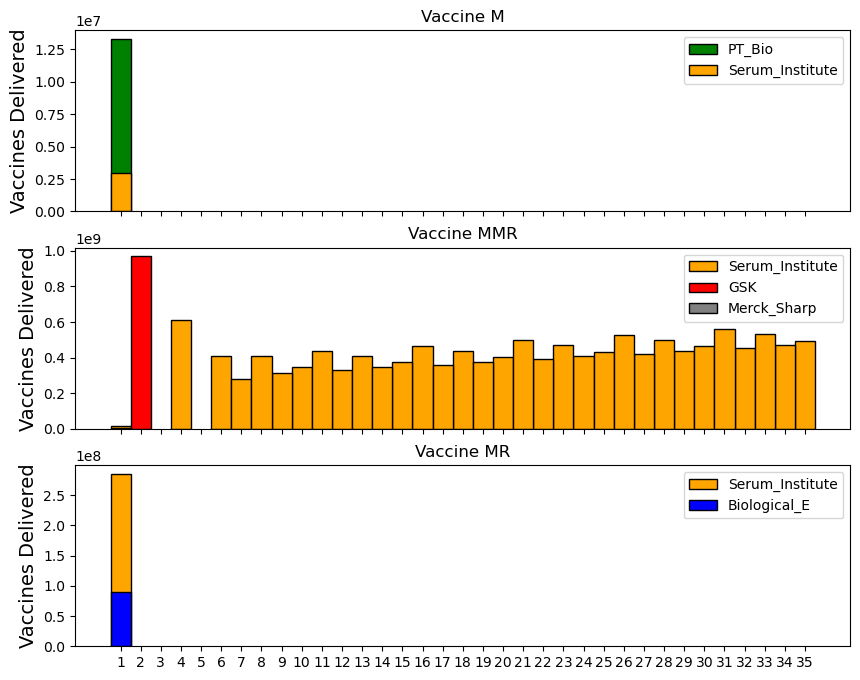

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    

# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
# plt.savefig('vax_as_antigens_35_MCV.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [28]:
#CHECK I levels
with open('Deterministic_results_F_Q_I_S_MMR_Penta_as_antigen_no_capacity_high_supply.json') as json_file:
    F_results = json.load(json_file)

    

# List of keywords to search for
keywords_to_search = ["I["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [29]:
# Extract the 'M' group
m_group = grouped_results.get('I[', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if ('MMR' in key for key in entry)
]

# filtered_dicts

In [30]:
import pandas as pd

data = [
    {'I[DTwP-Hib,7]': 0.0},
    {'I[Penta,0]': 12542.0},
    {'I[DTwP-Hib,6]': 0.0},
    {'I[HepB,29]': 0.0},
    {'I[DTwP,18]': 53097868.398522735},
]

# Extracting data and creating a DataFrame
df_data = []
for item in filtered_dicts:
    key, value = item.popitem()
    vaccine_start = key.find('I[') + 2
    vaccine_end = key.find(',', vaccine_start)
    year_start = vaccine_end + 1
    year_end = key.find(']', year_start)
    
    vaccine = key[vaccine_start:vaccine_end]
    year = key[year_start:year_end]
    
    df_data.append({'Vaccine': vaccine, 'Year': year, 'Value': value})

df = pd.DataFrame(df_data)

# Display the DataFrame
df


,Vaccine,Year,Value
0,PCV,0,5.145000e+03
1,IPV,31,0.000000e+00
2,TT,9,1.058984e+06
3,OPV,12,0.000000e+00
4,PCV,18,0.000000e+00
...,...,...,...
607,MR,31,0.000000e+00
608,Hexa,24,0.000000e+00
609,DTwP,24,0.000000e+00
610,TT,22,1.058984e+06


In [31]:
df[(df.Vaccine == "MMR") & (df.Value != 0)].sort_values(by='Year')

,Vaccine,Year,Value
444,MMR,2,322200000.0
221,MMR,4,313700000.0
